# Seoul Bike Demand Prediction — Stage-2 LightGBM tuning

Focused second-stage hyperparameter search around the best parameters from Stage 1. The target remains `log1p(Rented Bike Count)`, and MSE on the log-transformed target is used because it directly corresponds to the RMSLE objective.

In [1]:
# 1. Imports and configuration
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, GridSearchCV, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error, r2_score

warnings.filterwarnings("ignore")

BASE_DIR = os.getcwd()
TRAIN_PATH = os.path.join(BASE_DIR, "train.csv")
TEST_PATH = os.path.join(BASE_DIR, "test.csv")
SUB_PATH = os.path.join(BASE_DIR, "submission.csv")
PLOT_PATH = os.path.join(BASE_DIR, "training_vs_validation_mse.png")

print("Working directory:", BASE_DIR)


Working directory: /Users/kaushiksathyanathsingh/Documents/ML project/Regression


In [2]:
# 2. Preprocessing function
def preprocess_data(df, is_train=True):
    df_feat = df.copy()

    col_rename = {
        'Temperature(°C)': 'Temperature',
        'Humidity(%)': 'Humidity',
        'Wind speed (m/s)': 'Wind speed',
        'Visibility (10m)': 'Visibility',
        'Dew point temperature(°C)': 'Dew point temperature',
        'Solar Radiation (MJ/m2)': 'Solar Radiation',
        'Rainfall(mm)': 'Rainfall',
        'Snowfall (cm)': 'Snowfall'
    }
    df_feat = df_feat.rename(columns=col_rename)

    # Date/time features
    df_feat['Date_dt'] = pd.to_datetime(df_feat['Date'], format='%d/%m/%Y')
    df_feat['Year'] = df_feat['Date_dt'].dt.year
    df_feat['Month'] = df_feat['Date_dt'].dt.month
    df_feat['Day'] = df_feat['Date_dt'].dt.day
    df_feat['DayOfWeek'] = df_feat['Date_dt'].dt.dayofweek
    df_feat['Is_Weekend'] = (df_feat['DayOfWeek'] >= 5).astype(int)

    # Season correction
    month_to_season = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    }
    df_feat['Seasons'] = df_feat['Month'].map(month_to_season)

    # Cyclical encodings
    df_feat['Hour_sin'] = np.sin(2 * np.pi * df_feat['Hour'] / 24.0)
    df_feat['Hour_cos'] = np.cos(2 * np.pi * df_feat['Hour'] / 24.0)
    df_feat['Month_sin'] = np.sin(2 * np.pi * df_feat['Month'] / 12.0)
    df_feat['Month_cos'] = np.cos(2 * np.pi * df_feat['Month'] / 12.0)
    df_feat['DayOfWeek_sin'] = np.sin(2 * np.pi * df_feat['DayOfWeek'] / 7.0)
    df_feat['DayOfWeek_cos'] = np.cos(2 * np.pi * df_feat['DayOfWeek'] / 7.0)

    # Weather imputation and interactions
    num_cols = ['Temperature', 'Wind speed', 'Solar Radiation', 'Rainfall']
    for col in num_cols:
        if col in df_feat.columns:
            df_feat[col] = (
                df_feat.groupby(['Month', 'Hour'])[col]
                .transform(lambda x: x.fillna(x.median()))
            )
            df_feat[col] = df_feat[col].fillna(df_feat[col].median())

    df_feat['Is_Raining'] = (df_feat['Rainfall'] > 0).astype(int)
    df_feat['Is_Snowing'] = (df_feat['Snowfall'] > 0).astype(int)
    df_feat['Temp_Humidity_Interaction'] = (
        df_feat['Temperature'] * (df_feat['Humidity'] / 100.0)
    )
    df_feat['Temp_Solar_Interaction'] = (
        df_feat['Temperature'] * df_feat['Solar Radiation']
    )

    # Metadata
    drop_cols = ['Date', 'Date_dt', 'Kaggle_ID', 'Record_id']
    drop_cols = [c for c in drop_cols if c in df_feat.columns]
    df_feat = df_feat.drop(columns=drop_cols)

    # One-hot encoding
    return pd.get_dummies(
        df_feat,
        columns=['Seasons', 'Holiday', 'Functioning Day'],
        drop_first=True
    )


In [3]:
# 3. Load data
if not os.path.exists(TRAIN_PATH) or not os.path.exists(TEST_PATH):
    raise FileNotFoundError(
        "train.csv and test.csv must be in the notebook working directory."
    )

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print("\nTrain columns:")
print(train_df.columns.tolist())


Train shape: (7093, 16)
Test shape:  (2628, 15)

Train columns:
['Kaggle_ID', 'Date', 'Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Seasons', 'Holiday', 'Functioning Day', 'Record_id', 'Rented Bike Count']


In [4]:
# 4. Preprocess data
train_proc = preprocess_data(train_df, is_train=True)
test_proc = preprocess_data(test_df, is_train=False)

X_train = train_proc.drop(columns=['Rented Bike Count'])

# Train on log-transformed demand.
# This aligns the training objective with RMSLE-style evaluation.
y_train_raw = train_proc['Rented Bike Count']
y_train = np.log1p(y_train_raw)

X_test = test_proc

# Make train/test feature columns identical
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

print("Feature matrix:", X_train.shape)
print("Target transformation: log1p(Rented Bike Count)")


Feature matrix: (7093, 29)
Target transformation: log1p(Rented Bike Count)


In [5]:
# 5. Stage-2 focused hyperparameter search

from sklearn.model_selection import KFold, RandomizedSearchCV

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Stage 1 found:
# n_estimators       = 1000
# learning_rate      = 0.03
# num_leaves         = 60
# min_child_samples  = 30
# subsample          = 0.8 / 0.9
# colsample_bytree   = 0.9
#
# Stage 2 searches a smaller region around those values.

param_distributions = {
    'n_estimators': [700, 800, 900, 1000, 1100, 1200, 1400, 1600],
    'learning_rate': [0.015, 0.02, 0.025, 0.03, 0.035, 0.04],
    'num_leaves': [40, 50, 60, 70, 80],
    'min_child_samples': [20, 25, 30, 40, 50],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

base_model = LGBMRegressor(
    random_state=42,
    n_jobs=1,
    verbosity=-1
)

# IMPORTANT:
# y_train is already log1p(target).
# Therefore ordinary MSE on y_train is equivalent to RMSLE
# on the original target.
#
# Do NOT use neg_mean_squared_log_error here because that would
# apply log1p() a second time to the already-log-transformed target.

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=kf,
    n_jobs=-1,
    random_state=123,
    refit=True,
    return_train_score=True,
    verbose=1
)

print("Stage-2 random combinations tested:", 50)
print("Total CV model fits:", 50 * 5)
print("Selection metric: MSE on log1p(target) = RMSLE objective")


Stage-2 random combinations tested: 50
Total CV model fits: 250
Selection metric: MSE on log1p(target) = RMSLE objective


In [6]:
# 6. Run stage-2 hyperparameter search

search.fit(X_train, y_train)

best_params = search.best_params_

# Since y_train = log1p(original target), RMSE in log space
# is the RMSLE on the original target.
best_cv_rmsle = np.sqrt(-search.best_score_)

print("\nSTAGE-2 BEST PARAMETERS")

for key, value in best_params.items():
    print(f"{key:22s}: {value}")

print(f"\nBest mean CV RMSLE: {best_cv_rmsle:.6f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

STAGE-2 BEST PARAMETERS
subsample             : 0.8
num_leaves            : 80
n_estimators          : 1600
min_child_samples     : 25
learning_rate         : 0.02
colsample_bytree      : 0.8

Best mean CV RMSLE: 0.581841


In [7]:
# 7. Inspect the best stage-2 results

cv_table = pd.DataFrame(search.cv_results_)

best_results = cv_table[
    [
        'rank_test_score',
        'mean_train_score',
        'mean_test_score',
        'std_test_score',
        'params'
    ]
].copy()

best_results['mean_train_log_MSE'] = -best_results['mean_train_score']
best_results['mean_validation_log_MSE'] = -best_results['mean_test_score']

# RMSE in log1p space = RMSLE on the original target.
best_results['validation_RMSLE'] = np.sqrt(
    best_results['mean_validation_log_MSE']
)

best_results = best_results.sort_values('rank_test_score')

best_results[
    [
        'rank_test_score',
        'mean_train_log_MSE',
        'mean_validation_log_MSE',
        'validation_RMSLE',
        'std_test_score',
        'params'
    ]
].head(15)


,rank_test_score,mean_train_log_MSE,mean_validation_log_MSE,validation_RMSLE,std_test_score,params
43,1,0.010305,0.338539,0.581841,0.062127,"{'subsample': 0.8, 'num_leaves': 80, 'n_estima..."
15,2,0.021005,0.338690,0.581971,0.068776,"{'subsample': 0.8, 'num_leaves': 60, 'n_estima..."
44,3,0.004020,0.338694,0.581974,0.064549,"{'subsample': 1.0, 'num_leaves': 80, 'n_estima..."
7,4,0.025985,0.338987,0.582226,0.068701,"{'subsample': 0.8, 'num_leaves': 60, 'n_estima..."
1,5,0.028007,0.340647,0.583649,0.063847,"{'subsample': 1.0, 'num_leaves': 70, 'n_estima..."
33,6,0.009599,0.341177,0.584104,0.065866,"{'subsample': 0.9, 'num_leaves': 80, 'n_estima..."
25,7,0.039639,0.341406,0.584299,0.064934,"{'subsample': 0.8, 'num_leaves': 70, 'n_estima..."
17,8,0.020211,0.341910,0.584731,0.063064,"{'subsample': 0.9, 'num_leaves': 80, 'n_estima..."
37,9,0.017613,0.342720,0.585423,0.065279,"{'subsample': 0.9, 'num_leaves': 50, 'n_estima..."
36,10,0.036963,0.345090,0.587444,0.065185,"{'subsample': 1.0, 'num_leaves': 40, 'n_estima..."


In [8]:
# 8. Detailed 5-fold evaluation of the selected stage-2 model

def get_model(params=None):
    base_params = {
        'n_estimators': 1000,
        'learning_rate': 0.03,
        'num_leaves': 60,
        'min_child_samples': 30,
        'subsample': 0.85,
        'colsample_bytree': 0.9,
        'random_state': 42,
        'n_jobs': 1,
        'verbosity': -1
    }

    if params:
        base_params.update(params)

    return LGBMRegressor(**base_params)


best_model = get_model(best_params)

# y_train = log1p(original target), so MSE in this space is
# squared logarithmic error. Its square root is RMSLE.
cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=kf,
    scoring='neg_mean_squared_error',
    return_train_score=True,
    n_jobs=-1
)

train_log_mse = -cv_results['train_score']
val_log_mse = -cv_results['test_score']

train_rmsle = np.sqrt(train_log_mse)
val_rmsle = np.sqrt(val_log_mse)

fold_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Train RMSLE': train_rmsle,
    'Validation RMSLE': val_rmsle,
    'Train log MSE': train_log_mse,
    'Validation log MSE': val_log_mse
})

fold_results


,Fold,Train RMSLE,Validation RMSLE,Train log MSE,Validation log MSE
0,1,0.091957,0.665771,0.008456,0.443251
1,2,0.101352,0.567179,0.010272,0.321691
2,3,0.099166,0.542081,0.009834,0.293852
3,4,0.111065,0.516090,0.012335,0.266348
4,5,0.103084,0.606262,0.010626,0.367553


In [9]:
# 9. Print CV summary

print("STAGE-2 5-FOLD CROSS-VALIDATION SUMMARY")

print(f"Mean Train RMSLE      : {np.mean(train_rmsle):.6f}")
print(f"Mean Validation RMSLE : {np.mean(val_rmsle):.6f}")
print(f"Validation RMSLE SD   : {np.std(val_rmsle):.6f}")

gap = np.mean(val_rmsle) - np.mean(train_rmsle)
print(f"Generalization gap    : {gap:.6f}")


STAGE-2 5-FOLD CROSS-VALIDATION SUMMARY
Mean Train RMSLE      : 0.101325
Mean Validation RMSLE : 0.579476
Validation RMSLE SD   : 0.052406
Generalization gap    : 0.478152


In [10]:
# 10. Training vs validation RMSLE as number of trees increases

best_n_estimators = best_params['n_estimators']

curve_estimators = sorted(set([
    400, 600, 800, 900, 1000,
    1100, 1200, 1400, 1600,
    best_n_estimators
]))

curve_train_rmsle = []
curve_val_rmsle = []

curve_params = best_params.copy()

for n_estimators in curve_estimators:
    curve_params['n_estimators'] = n_estimators
    model = get_model(curve_params)

    result = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_mean_squared_error',
        return_train_score=True,
        n_jobs=-1
    )

    curve_train_rmsle.append(
        np.mean(np.sqrt(-result['train_score']))
    )
    curve_val_rmsle.append(
        np.mean(np.sqrt(-result['test_score']))
    )

curve_df = pd.DataFrame({
    'n_estimators': curve_estimators,
    'Training RMSLE': curve_train_rmsle,
    'Validation RMSLE': curve_val_rmsle
})

curve_df


,n_estimators,Training RMSLE,Validation RMSLE
0,400,0.308245,0.583914
1,600,0.237909,0.579975
2,800,0.191203,0.578982
3,900,0.173359,0.578898
4,1000,0.158011,0.579099
5,1100,0.145149,0.578924
6,1200,0.134260,0.579221
7,1400,0.115785,0.579460
8,1600,0.101325,0.579476


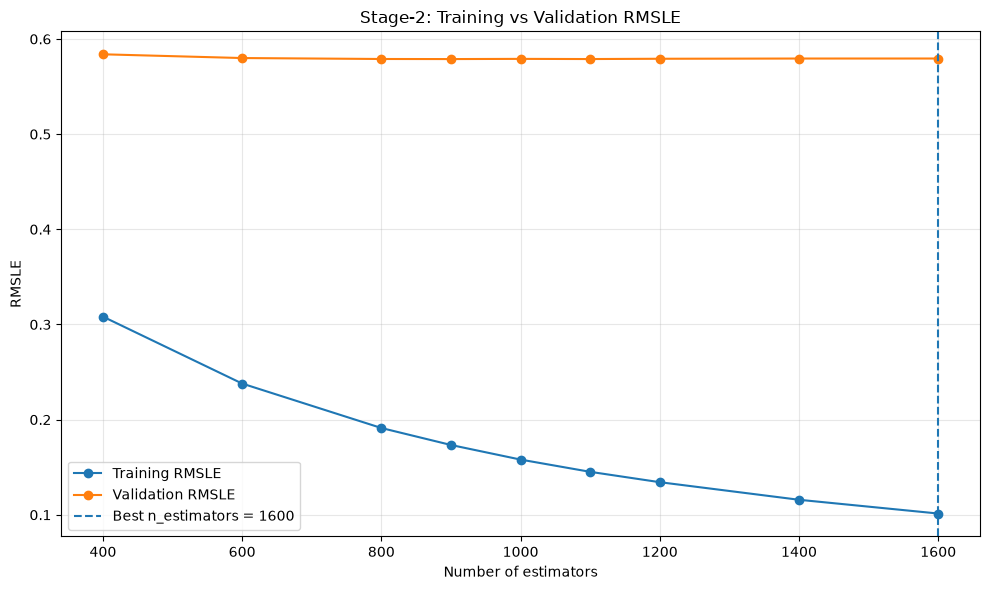

In [11]:
# 11. Plot training and validation RMSLE

plt.figure(figsize=(10, 6))

plt.plot(
    curve_estimators,
    curve_train_rmsle,
    marker='o',
    label='Training RMSLE'
)

plt.plot(
    curve_estimators,
    curve_val_rmsle,
    marker='o',
    label='Validation RMSLE'
)

plt.axvline(
    best_n_estimators,
    linestyle='--',
    label=f'Best n_estimators = {best_n_estimators}'
)

plt.xlabel('Number of estimators')
plt.ylabel('RMSLE')
plt.title('Stage-2: Training vs Validation RMSLE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(PLOT_PATH, dpi=150)
plt.show()


In [12]:
# 12. Train final model on all training data
final_model = get_model(best_params)
final_model.fit(X_train, y_train)

print("Final model trained.")


Final model trained.


In [13]:
# 13. Test error, if test labels are available

if 'Rented Bike Count' in test_df.columns:
    # Model predicts log1p(demand), so transform back first.
    test_pred_log = final_model.predict(X_test)
    test_preds = np.expm1(test_pred_log)
    test_preds = np.clip(test_preds, 0, None)

    y_test = test_df['Rented Bike Count'].values

    test_rmsle = np.sqrt(
        mean_squared_log_error(y_test, test_preds)
    )

    test_mse = mean_squared_error(y_test, test_preds)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, test_preds)
    test_r2 = r2_score(y_test, test_preds)

    print("TRUE TEST ERROR")
    print(f"Test RMSLE : {test_rmsle:.6f}")
    print(f"Test MSE   : {test_mse:.2f}")
    print(f"Test RMSE  : {test_rmse:.2f}")
    print(f"Test MAE   : {test_mae:.2f}")
    print(f"Test R²    : {test_r2:.4f}")

else:
    print("test.csv has no 'Rented Bike Count'.")
    print("A true test error cannot be calculated.")
    print(f"5-fold CV validation RMSLE: {np.mean(val_rmsle):.6f}")


test.csv has no 'Rented Bike Count'.
A true test error cannot be calculated.
5-fold CV validation RMSLE: 0.579476


In [14]:
# 14. Generate submission

# Predict in log-space, then convert back to the original demand scale.
test_pred_log = final_model.predict(X_test)

test_preds = np.expm1(test_pred_log)
test_preds = np.clip(test_preds, 0, None)

test_preds_rounded = np.round(test_preds).astype(int)

if 'Kaggle_ID' in test_df.columns:
    sub_df = pd.DataFrame({
        'Kaggle_ID': test_df['Kaggle_ID'],
        'Rented Bike Count': test_preds_rounded
    })
else:
    sub_df = pd.DataFrame({
        'Rented Bike Count': test_preds_rounded
    })

sub_df.to_csv(SUB_PATH, index=False)

print("Saved submission:", SUB_PATH)
print(sub_df.head())


Saved submission: /Users/kaushiksathyanathsingh/Documents/ML project/Regression/submission.csv
   Kaggle_ID  Rented Bike Count
0          0                475
1          1                828
2          2                413
3          3                389
4          4                294
